In [1]:
%run CleanData.ipynb

# ==================== IMPORTS ====================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Classes: [0 1 2 3 4 5] | Count: 6


In [2]:
# ==================== TRAIN MODEL ====================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [3]:
# ==================== PREDICTION ====================
y_pred = rf_model.predict(X_test)

In [4]:
# ==================== EVALUATE MODEL ====================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9541587711163972
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     18952
           1       0.98      0.59      0.73       556
           2       0.98      0.87      0.93      1448
           3       0.83      0.60      0.70       162
           4       0.99      0.94      0.97      1608
           5       0.98      0.74      0.85      2077

    accuracy                           0.95     24803
   macro avg       0.95      0.79      0.86     24803
weighted avg       0.96      0.95      0.95     24803

Confusion Matrix:
 [[18917     8     4     3     2    18]
 [  227   326     0     0     1     2]
 [  157     0  1265    16     4     6]
 [   53     0    12    97     0     0]
 [   83     0     3     0  1518     4]
 [  531     0     1     1     1  1543]]


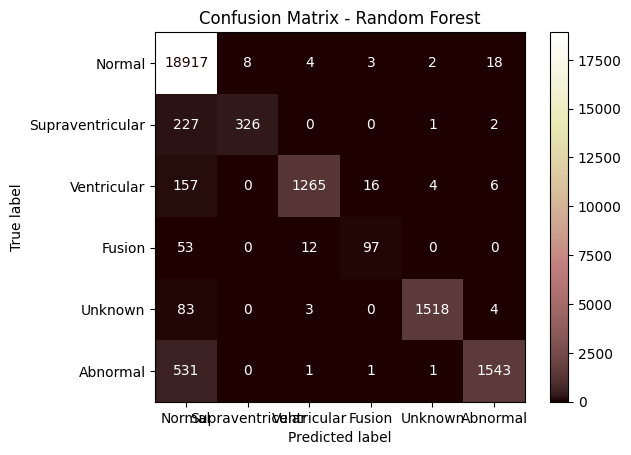

In [5]:
# ==================== PLOT CONFUSION MATRIX ====================
label_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown', 'Abnormal']
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='pink')
plt.title("Confusion Matrix - Random Forest")
plt.show()